# 02 — Price Model & Deal Scorer

**Goal of this notebook:** build a model that estimates a fair price for a listing,
then turn that estimate into the product's hero feature — a great / good / bad deal
score. We build it the way a data scientist actually works: start with the dumbest
possible model, measure it, then only add complexity that earns its keep.

**Step 1 — A baseline to beat**

Before any machine learning, we need a reference point. The simplest "model" imaginable:
**ignore every feature and always predict the average price.** It sounds useless — and it
is — but it gives us a number to measure against. If a real model can't beat "just guess
the mean," the model is worthless.

We measure with three standard regression metrics:
- **MAE** (mean absolute error): on average, how many euros are we off? Easy to explain.
- **RMSE** (root mean squared error): like MAE but punishes big misses harder.
- **R²**: what fraction of price variation the model explains. 0 = no better than the mean,
  1 = perfect. A baseline that predicts the mean scores **R² = 0 by definition** — that's
  our floor.

We train on `ml_df` (the cleaned, outlier-free dataset from preprocessing).

In [1]:
import os, sys
from pathlib import Path

# Step up to project root so "from backend import ..." works (same as notebook 01).
if Path.cwd().name == "notebooks":
    os.chdir("..")
sys.path.insert(0, str(Path.cwd()))

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from backend import preprocessing

# Get the ML dataset (cleaned + outliers removed) from our single source of truth.
_, ml_df = preprocessing.run()
print(f"ML dataset: {len(ml_df)} rows")

# Same split the model module uses, so every number in this notebook is comparable.
TARGET = "price_in_euro"
y = ml_df[TARGET].astype(float)
X = ml_df.drop(columns=[TARGET])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# The baseline: predict the mean training price for every listing.
baseline_pred = np.full(shape=len(y_test), fill_value=y_train.mean())

mae = mean_absolute_error(y_test, baseline_pred)
rmse = mean_squared_error(y_test, baseline_pred) ** 0.5
r2 = r2_score(y_test, baseline_pred)

print("\n--- Baseline: always predict the mean ---")
print(f"Mean training price : €{y_train.mean():,.0f}")
print(f"MAE                 : €{mae:,.0f}")
print(f"RMSE                : €{rmse:,.0f}")
print(f"R2                  : {r2:.3f}")

ML dataset: 4329 rows

--- Baseline: always predict the mean ---
Mean training price : €186,003
MAE                 : €80,240
RMSE                : €112,277
R2                  : -0.007


**Step 2 — A first real model (and why we reuse `model.py`)**

Now we beat the baseline. Instead of writing model code from scratch in the notebook, we
call `train_model` from `backend/model.py` — the same function the website and the AI
assistant will use later. This is the core habit of the project: **the logic lives in one
module, and everything reuses it.**

`model.py` packages a complete recipe behind one call:
- it selects our evidence-based features (`square_meters`, `bedrooms`, `bathrooms`,
  `floor`, `has_elevator`, `furnishing_status`),
- fills missing values, one-hot encodes the furnishing category, and
- trains on `log(price)` to handle the skew we saw in notebook 01.

The function also lets us **swap the estimator** while keeping that recipe fixed. We start
with the simplest real model — **Linear Regression** — so any improvement we make later is
measured against an honest, simple first attempt.

In [2]:
from sklearn.linear_model import LinearRegression
from backend import model

# Carry the baseline numbers over from Step 1 (still in memory).
baseline = {"MAE": mae, "RMSE": rmse, "R2": r2}

# Same packaged pipeline (features + encoding + log-target); only the estimator changes.
linear_model, linear_metrics = model.train_model(ml_df, estimator=LinearRegression())

print("Features the model uses:", model.FEATURES)
print()
print(f"Baseline (mean) : MAE €{baseline['MAE']:,.0f} | RMSE €{baseline['RMSE']:,.0f} | R2 {baseline['R2']:.3f}")
print(f"Linear model    : MAE €{linear_metrics['MAE']:,.0f} | RMSE €{linear_metrics['RMSE']:,.0f} | R2 {linear_metrics['R2']:.3f}")
print()
print(f"MAE improved by €{baseline['MAE'] - linear_metrics['MAE']:,.0f}")
print(f"R2  improved by {linear_metrics['R2'] - baseline['R2']:.3f}")

Features the model uses: ['square_meters', 'bedrooms', 'bathrooms', 'floor', 'has_elevator', 'dist_to_center_km', 'location_score', 'furnishing_status', 'zone']

Baseline (mean) : MAE €80,240 | RMSE €112,277 | R2 -0.007
Linear model    : MAE €48,279 | RMSE €112,426 | R2 -0.010

MAE improved by €31,961
R2  improved by -0.003


**Step 3 — A model that can't blow up: Random Forest**

The linear model failed in an interesting way: a few predictions exploded when we
converted out of log-space. A **Random Forest** can't do that. It predicts by averaging
actual prices from similar listings it saw in training, so its output is always bounded by
the real prices in the data — no extrapolation into the exponential's danger zone.

We change exactly **one thing**: the estimator. Same features, same encoding, same
log-target, same train/test split. That's the whole point of putting the recipe in
`model.py` — comparing models is a one-line change, and the comparison is fair because
everything else is held constant. Random Forest is also `train_model`'s default, so this
is the model the website and the assistant will actually use.

In [3]:
# Random Forest is the default estimator in train_model — no estimator argument needed.
rf_model, rf_metrics = model.train_model(ml_df)

# Compare all three on the same test set.
print(f"{'model':18}{'MAE':>12}{'RMSE':>12}{'R2':>9}")
print("-" * 51)
for name, mtr in [("Baseline (mean)", baseline),
                  ("Linear (log)", linear_metrics),
                  ("Random Forest", rf_metrics)]:
    print(f"{name:18}€{mtr['MAE']:>10,.0f}€{mtr['RMSE']:>10,.0f}{mtr['R2']:>9.3f}")

model                      MAE        RMSE       R2
---------------------------------------------------
Baseline (mean)   €    80,240€   112,277   -0.007
Linear (log)      €    48,279€   112,426   -0.010
Random Forest     €    36,483€    59,280    0.719


## Step 3b — Comparing candidate models and the final blend

Linear Regression and Random Forest were already tested in Steps 2 and 3. This section compares five additional regression algorithms, tuned versions of ExtraTrees and HistGradientBoosting, and a final 50/50 blend of the two strongest models.

The same data, features, preprocessing, log-target transformation and train/test split are used throughout. Although the models train on `log(price)`, predictions are converted back to euros before MAE, RMSE and R² are calculated.

All results are ranked by MAE, where lower is better. The best-performing candidate becomes the final model used for prediction and deal scoring.

=== ALL MODELS RANKED BY MAE ===


,model,MAE,RMSE,R2
1,Blend 50/50,34681.718985,55702.561499,0.752178
2,ExtraTrees,35715.218088,58178.885480,0.729654
3,ExtraTrees tuned,35783.399457,58302.477313,0.728504
4,HistGB tuned,35959.321151,56903.467522,0.741377
5,Random Forest,36483.211705,59279.526526,0.719328
6,XGBoost,36835.535219,58928.066342,0.722646
7,HistGradientBoosting,36915.680407,59052.719813,0.721472
8,LightGBM,37034.341694,59112.937720,0.720903
9,GradientBoosting,38291.059997,61288.430632,0.699983
10,Linear (log),48279.148829,112426.373798,-0.009545


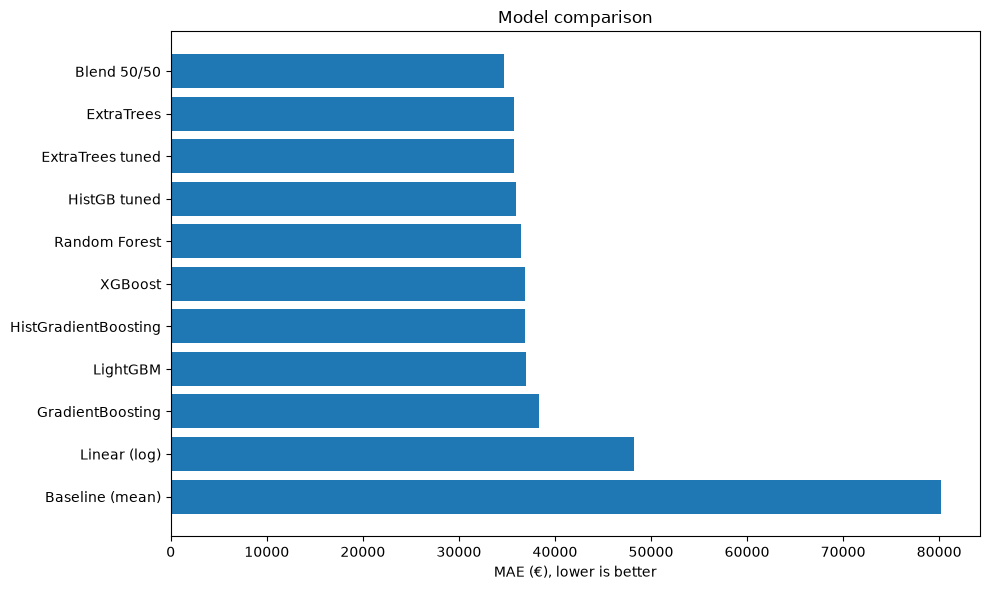

Winner: Blend 50/50 | MAE €34,682 | RMSE €55,703 | R2 0.752


In [4]:
import numpy as np,pandas as pd,matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor,ExtraTreesRegressor,HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from backend import model

candidates={
    "GradientBoosting":GradientBoostingRegressor(n_estimators=500,max_depth=3,learning_rate=.03,subsample=.8,random_state=42),
    "ExtraTrees":ExtraTreesRegressor(n_estimators=400,random_state=42,n_jobs=-1),
    "HistGradientBoosting":HistGradientBoostingRegressor(max_iter=400,learning_rate=.05,max_depth=6,random_state=42),
    "XGBoost":XGBRegressor(n_estimators=500,max_depth=5,learning_rate=.03,subsample=.8,colsample_bytree=.8,random_state=42),
    "LightGBM":LGBMRegressor(n_estimators=500,max_depth=6,learning_rate=.03,subsample=.8,colsample_bytree=.8,random_state=42,verbose=-1)
}

rows=[]
for name,estimator in candidates.items():
    fitted,metrics=model.train_model(ml_df,estimator=estimator)
    rows.append({"model":name,"MAE":metrics["MAE"],"RMSE":metrics["RMSE"],"R2":metrics["R2"]})

X=model.build_features(ml_df)
y=ml_df[model.TARGET].astype("float64")
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=42)

et=model._build_pipeline(ExtraTreesRegressor(n_estimators=800,min_samples_leaf=1,max_features=.6,max_depth=None,random_state=42,n_jobs=-1),use_log_target=True)
hgb=model._build_pipeline(HistGradientBoostingRegressor(max_iter=800,max_depth=None,learning_rate=.02,l2_regularization=1,random_state=42),use_log_target=True)

et.fit(X_train,y_train)
hgb.fit(X_train,y_train)
et_pred=et.predict(X_test)
hgb_pred=hgb.predict(X_test)
blend_pred=(et_pred+hgb_pred)/2

def add_result(name,pred):
    rows.append({"model":name,"MAE":mean_absolute_error(y_test,pred),"RMSE":mean_squared_error(y_test,pred)**.5,"R2":r2_score(y_test,pred)})

add_result("ExtraTrees tuned",et_pred)
add_result("HistGB tuned",hgb_pred)
add_result("Blend 50/50",blend_pred)

rows+=[
    {"model":"Baseline (mean)","MAE":baseline["MAE"],"RMSE":baseline["RMSE"],"R2":baseline["R2"]},
    {"model":"Linear (log)","MAE":linear_metrics["MAE"],"RMSE":linear_metrics["RMSE"],"R2":linear_metrics["R2"]},
    {"model":"Random Forest","MAE":rf_metrics["MAE"],"RMSE":rf_metrics["RMSE"],"R2":rf_metrics["R2"]}
]

comparison_df=pd.DataFrame(rows).sort_values("MAE").reset_index(drop=True)
comparison_df.index=np.arange(1,len(comparison_df)+1)

print("=== ALL MODELS RANKED BY MAE ===")
display(comparison_df)

plt.figure(figsize=(10,6))
plt.barh(comparison_df["model"],comparison_df["MAE"])
plt.xlabel("MAE (€), lower is better")
plt.title("Model comparison")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

winner=comparison_df.iloc[0]
print(f"Winner: {winner['model']} | MAE €{winner['MAE']:,.0f} | RMSE €{winner['RMSE']:,.0f} | R2 {winner['R2']:.3f}")

## Step 4 — Open the box: is the final model sensible?

Our final 50/50 blend achieved an R² of approximately 0.75. Before trusting it, we inspect how the model succeeds and fails using two views:

- **Predicted vs actual.** Each listing is shown as a point, comparing the predicted price with the listed price. A perfect model would place every point on the diagonal. The closer the points are to this line, the more accurate the predictions are.

- **Permutation feature importance.** Because the final model is a blend, we measure feature importance by randomly shuffling one feature at a time and observing how much the MAE increases. A larger increase means that the model relies more heavily on that feature. The most important features were `square_meters`, `zone`, `location_score`, `bathrooms`, `floor`, and `dist_to_center_km`.

These checks help confirm that the model is using sensible property and location information rather than relying on an accidental leak or irrelevant feature.

Blend 50/50 | MAE €34,682 | RMSE €55,703 | R2 0.752


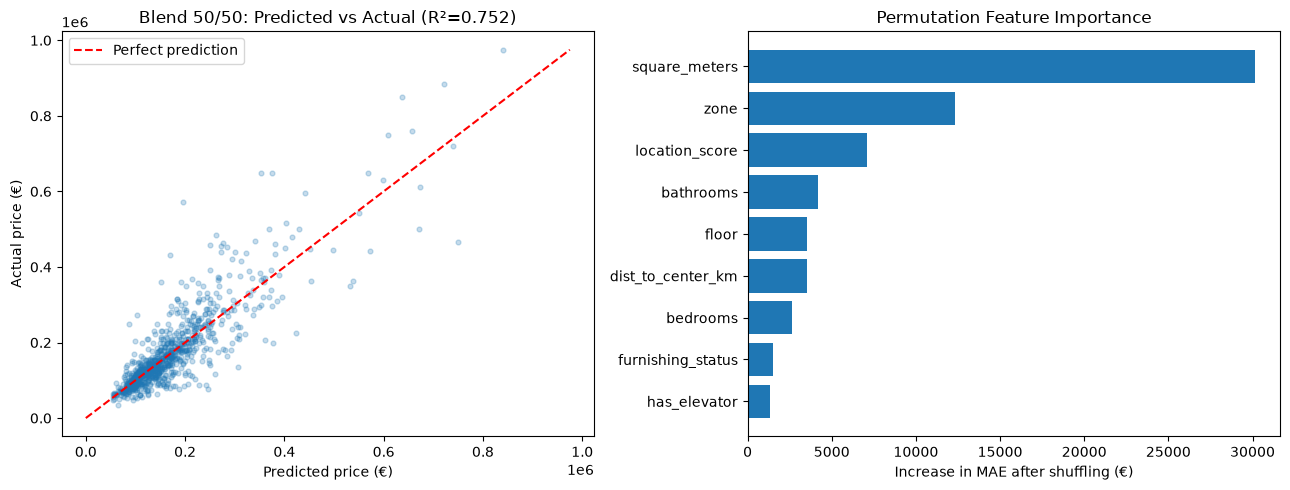


Top features:
square_meters             €30,126
zone                      €12,305
location_score            €7,121
bathrooms                 €4,203
floor                     €3,537
dist_to_center_km         €3,517


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

def blend_predict(data):
    return (et.predict(data)+hgb.predict(data))/2

preds=blend_predict(X_test)
mae=mean_absolute_error(y_test,preds)
rmse=mean_squared_error(y_test,preds)**0.5
r2=r2_score(y_test,preds)

print(f"Blend 50/50 | MAE €{mae:,.0f} | RMSE €{rmse:,.0f} | R2 {r2:.3f}")

rng=np.random.default_rng(42)
importances=[]

for col in X_test.columns:
    shuffled=X_test.copy()
    shuffled[col]=rng.permutation(shuffled[col].values)
    shuffled_mae=mean_absolute_error(y_test,blend_predict(shuffled))
    importances.append(shuffled_mae-mae)

order=np.argsort(importances)

fig,axes=plt.subplots(1,2,figsize=(13,5))

axes[0].scatter(preds,y_test,alpha=.25,s=12)
lims=[0,max(y_test.max(),preds.max())]
axes[0].plot(lims,lims,"r--",label="Perfect prediction")
axes[0].set_xlabel("Predicted price (€)")
axes[0].set_ylabel("Actual price (€)")
axes[0].set_title(f"Blend 50/50: Predicted vs Actual (R²={r2:.3f})")
axes[0].legend()

axes[1].barh(np.array(X_test.columns)[order],np.array(importances)[order])
axes[1].set_xlabel("Increase in MAE after shuffling (€)")
axes[1].set_title("Permutation Feature Importance")

plt.tight_layout()
plt.show()

print("\nTop features:")
for i in order[::-1][:6]:
    print(f"{X_test.columns[i]:25s} €{importances[i]:,.0f}")

## Step 5 — The hero feature: great / good / bad deals

A price prediction alone is useful, but the main product question is:

**Is this listing potentially a good deal?**

We answer it by comparing the listing's asking price with the price predicted by the final 50/50 blend:

`gap = (predicted price - listed price) / predicted price`

A positive gap means that the listing is cheaper than the model's prediction. The gap is converted into three grades using the thresholds defined in `model.py`:

- **great** — listed at least 15% below the predicted price
- **good** — listed between 5% and 15% below the predicted price
- **bad** — fairly priced or overpriced

For an honest evaluation, this section applies deal scoring only to the unseen test listings. These properties were not used to train the models.

Two checks are performed:

1. **Are the thresholds sensible for the data?**  
   We inspect the distribution of listings across the three grades. If nearly all listings fall into one category, the thresholds may require adjustment.

2. **Do the highest-ranked great deals look believable?**  
   We inspect the listings with the largest positive gaps to check whether the results are realistic.

The same `score_deal` function from `model.py` is used here and can later be used by the website or application.

Deal grade distribution:
grade
bad      524
great    206
good     136
Name: count, dtype: int64

Deal grade percentages:
grade
bad      60.5 %
great    23.8 %
good     15.7 %
Name: proportion, dtype: str


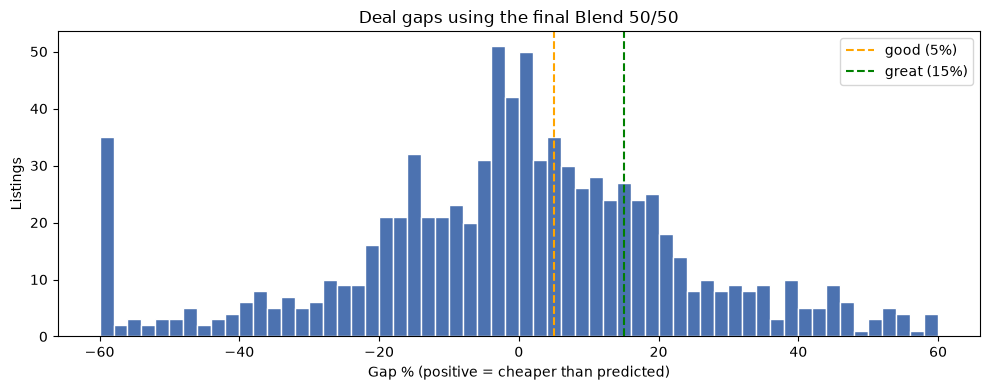


Top 5 great deals:


,listing_id,price_in_euro,predicted,gap_pct,grade,square_meters,bedrooms,address,zone
3621,3763,78000.0,245552.581006,68.234909,great,101.02,3.0,"Rruga Skender Luarasi, Tiranë, Albania",Blloku
893,923,88000.0,242627.185156,63.730363,great,91.00,2.0,B-1,Astir
3679,3824,86600.0,228752.376068,62.142470,great,110.59,2.0,"Petrelë, Albania",Astir
3415,3545,77700.0,186751.655964,58.393943,great,91.45,2.0,"Plaza Tirana, Sheshi Skender Beu, Tirana 1001,...",Qendra (Skenderbej)
1309,1355,85000.0,197021.085117,56.857409,great,127.00,2.0,"kodra e diellit, Tiranë, Shqipëri",Don Bosko


In [6]:
from backend import model
import matplotlib.pyplot as plt

# Use only unseen test listings for an honest deal evaluation.
work=ml_df.loc[X_test.index].copy()
work["predicted"]=(et.predict(X_test)+hgb.predict(X_test))/2

work["gap_pct"]=(
    (work["predicted"]-work["price_in_euro"])
    /work["predicted"]*100
)

work["grade"]=[
    model.score_deal(predicted,actual)["grade"]
    for predicted,actual in zip(
        work["predicted"],
        work["price_in_euro"]
    )
]

print("Deal grade distribution:")
print(work["grade"].value_counts())

print("\nDeal grade percentages:")
print(
    (work["grade"].value_counts(normalize=True)*100)
    .round(1)
    .astype(str)+" %"
)

plt.figure(figsize=(10,4))
plt.hist(
    work["gap_pct"].clip(-60,60),
    bins=60,
    color="#4C72B0",
    edgecolor="white"
)
plt.axvline(
    model.GOOD_DEAL_GAP*100,
    color="orange",
    linestyle="--",
    label="good (5%)"
)
plt.axvline(
    model.GREAT_DEAL_GAP*100,
    color="green",
    linestyle="--",
    label="great (15%)"
)
plt.xlabel("Gap % (positive = cheaper than predicted)")
plt.ylabel("Listings")
plt.title("Deal gaps using the final Blend 50/50")
plt.legend()
plt.tight_layout()
plt.show()

cols=[
    "listing_id",
    "price_in_euro",
    "predicted",
    "gap_pct",
    "grade",
    "square_meters",
    "bedrooms",
    "address",
    "zone"
]
cols=[col for col in cols if col in work.columns]

print("\nTop 5 great deals:")
display(
    work[work["grade"]=="great"]
    .sort_values("gap_pct",ascending=False)[cols]
    .head(5)
)

## Step 6 — Save the final model for the web app

The model only matters if other parts of the project can use it. We save the final 50/50 blend as a single file with `joblib`. The saved model contains both trained pipelines: ExtraTrees and HistGradientBoosting, together with their preprocessing, encoding and log-target transformations.

Because the complete model is saved together, the website uses the same transformations and prediction logic that were validated in this notebook.

We save it through `model.save_model()`, writing to `models/model.joblib`. The website and the AI assistant can then load this file with `model.load_model()`, predict prices with `predict_price`, and classify listings with `score_deal`.

This completes the data-and-model phase:

`raw JSON → cleaned data → trained Blend 50/50 → saved model → deal scoring`

In [7]:
from sklearn.ensemble import VotingRegressor
from backend import model

X=model.build_features(ml_df)
y=ml_df[model.TARGET].astype("float64")

final_model=VotingRegressor(
    estimators=[
        ("extra_trees",et),
        ("hist_gradient_boosting",hgb)
    ],
    weights=[0.5,0.5],
    n_jobs=-1
)

# Retrain the final blend on all available listings.
final_model.fit(X,y)

model.save_model(final_model)
print(f"Saved final Blend 50/50 -> {model.MODEL_PATH}")

# Confirm that the saved model reloads correctly.
reloaded=model.load_model()
sample=ml_df.iloc[0].to_dict()

pred_mem=model.predict_price(final_model,sample)
pred_disk=model.predict_price(reloaded,sample)

print(f"\nSample listing: listed €{sample['price_in_euro']:,.0f}")
print(f"Prediction (in-memory): €{pred_mem:,.0f}")
print(f"Prediction (from disk): €{pred_disk:,.0f}")
print(f"Match: {np.isclose(pred_mem,pred_disk)}")

deal=model.score_deal(pred_disk,sample["price_in_euro"])
print(f"Deal grade: {deal['grade']} ({deal['gap_pct']:+.1f}% vs predicted)")

Saved final Blend 50/50 -> models\model.joblib

Sample listing: listed €400,000
Prediction (in-memory): €370,437
Prediction (from disk): €370,437
Match: True
Deal grade: bad (-8.0% vs predicted)
